- AICE Associate 모의고사
  - 장바구나 이탈 여부 예측

- 장바구니 이탈 가능성이 높은 고객을 사전에 예측하여 마케팅 자동화 시스템에 활용할 수 있도록 고객 특성 데이터를 기반으로 예측 모델 구축
- 온라인 쇼핑몰을 운영하는 A사는 최근 장바구니 이탈률이 높아짐에 따라 매출 손실이 증가
- 고객이 상품을 장바구니에 담고도 구매까지 이어지지 않는 경우가 많아 이를 사전에 예측하고자 함
- 이에 따라 기업은 실제 장바구니 이탈 여부와 고객의 기본 정보를 포함한 데이터를 수집하였으며, 다음 조건을 기반으로 장바구니 이탈 여부(cart_abandon_yn)를 예측하는 모델 구축 진행
- 모든 문항은 실전 기반의 데이터 전처리, 시각화, 모델 학습 및 평가를 포함하고 있으며 수험자는 제한된 시간안에 주어진 데이터를 분석하고 적잘한 판단을 내려야 함
- 총 시험 시간은 90분이며 시간 내에 모든 문항에 답안 작성 필요

| 칼럼 명 | 설명 | 
| --- | --- |
| cart_value | 장바구니 금액 (USD) |
| num_items | 바구니에 담긴 상품 수 |
| device | 접속 기기(mobile, tablet, desktop) |
| time_on_site | 사이트 체류 시간 (분) |
| prev_purchase | 기존 구매 이력 여부 (Y, N) |
| country | 접속 국가 (US, CN, JP, Others 등) |
| payment_method | 결제 수단 (card, paypal 등) |
| discount_applied | 할인 적용 여부 (Y, N) |
| user_type | 사용자 유형(guest / registered) |
| cart_abandon_yn | 장바구니 이탈 여부(1: 이탈, 0: 구매 완료) <- 예측 대상 |

1. 장바구니 이탈 여부 예측을 위해 필요한 라이브러리 임포트
   - 목표: pandas, numpy, seaborn, matplotlib을 임포트
   - 조건: seaborn은 sns, matplotlib.pyplot은 plt로 별칭(alias) 지정

In [1]:
import pandas
import numpy
import seaborn as sns
import matplotlib.pyplot as plt

2. 문제를 해결하기 위해, 분석 및 처이할 데이터 파일을 읽어옴
   - pandas를 이용해서 cart_abandon.csv 파일을 불러오세요
     - 목표: 파일을 읽어 abandon_df 라는 이름의 데이터프레임에 저장
     - 조건: 파일명 cart_abandon.csv (해당 데이터는 dataset 폴더 안에 존재)

In [2]:
abandon_df = pandas.read_csv("datasets/cart_abandon.csv")

In [3]:
abandon_df.head()

,cart_value,num_items,device,time_on_site,prev_purchase,country,payment_method,discount_applied,user_type,cart_abandon_yn
0,267.87,5,mobile,NaN,Y,JP,card,N,guest,1
1,293.92,5,tablet,8.54,Y,CN,card,N,registered,0
2,33.67,9,mobile,7.16,Y,US,paypal,N,guest,0
3,102.33,8,tablet,4.13,N,CN,card,Y,guest,0
4,348.93,6,mobile,7.59,N,Others,card,N,guest,0


3. 사용자의 회원 유형(user_type)에 따라 웹사이트 체류 시간(time_on_site)이 어떻게 다른지를 Seaborn을 이용하여 시각화를 통해 분석
   - 목표: Seaborn의 boxplot()을 사용하여 시각화하고, 결과를 바탕으로 해석을 선택, 결과는 "답04" 변수에 저장
   - 조건: x = user_type, y = time_on_site
     
   1. registered 사용자가 guest보다 평균과 중앙값 모두 높고, 이상치도 많다
   2. guset 사용자는 registered보다 체류 시간이 약간 더 길며, 평균과 중앙값 모두 더 높다
   3. 두 그룹의 중앙값은 같지만, guest는 이상치가 많아 평균만 더 높다
   4. guest는 이상치가 없고 registered는 이상치로 인해 중앙값이 낮아졌다

<Axes: xlabel='user_type', ylabel='time_on_site'>

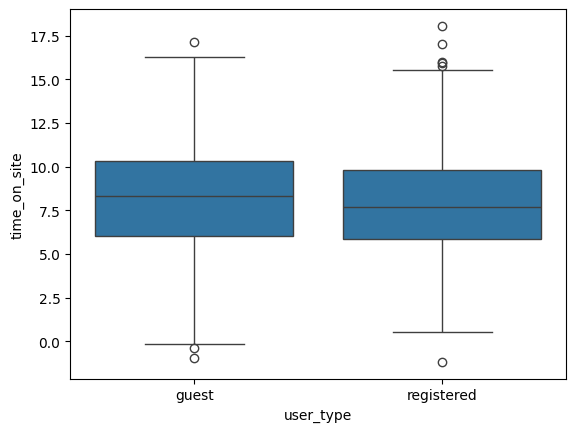

In [4]:
sns.boxplot(data=abandon_df, x="user_type", y="time_on_site")

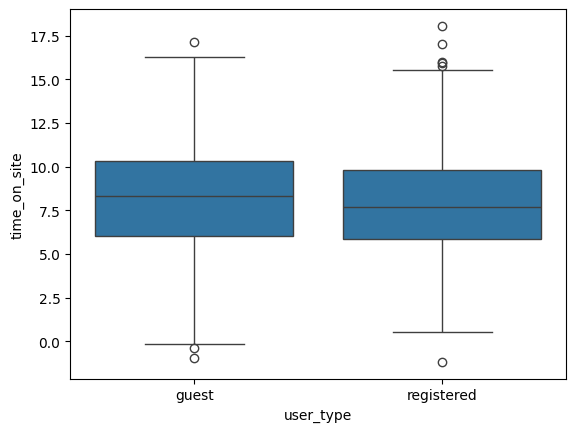

In [5]:
abandon_df.groupby("user_type")["time_on_site"].mean()
sns.boxplot(data=abandon_df, x="user_type", y="time_on_site")
답04 = 2

4. 데이터 모델링을 하기 위해 결측치 처리를 진행, 다음의 조건을 이용하여 결측치를 처리
   - 목표: "time_on_site" 컬럼의 결측치를 중앙값(median)으로 채움, "cart_value" 컬럼의 결측치를 평균(mean)으로 채움
   - 조건: inplace = True를 이용해서 처리

In [6]:
abandon_df.isnull().sum()

cart_value          52
num_items            0
device               0
time_on_site        52
prev_purchase        0
country              0
payment_method       0
discount_applied     0
user_type            0
cart_abandon_yn      0
dtype: int64

In [7]:
abandon_df["time_on_site"].fillna(abandon_df["time_on_site"].median(), inplace=True)
abandon_df["cart_value"].fillna(abandon_df["cart_value"].mean(), inplace=True)

/tmp/ipykernel_122682/97328326.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  abandon_df["time_on_site"].fillna(abandon_df["time_on_site"].median(), inplace=True)
/tmp/ipykernel_122682/97328326.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [8]:
abandon_df.isnull().sum()

cart_value          0
num_items           0
device              0
time_on_site        0
prev_purchase       0
country             0
payment_method      0
discount_applied    0
user_type           0
cart_abandon_yn     0
dtype: int64

5. 범주형 변수들을 모델 학습에 사용할 수 있도록 Pandas의 get_dummies()를 사용하여 숫자형으로 변환(원-핫 인코딩) 진행
   - 목표: drop_first=True 옵션 사용
   - "incoding_df" 변수에 처리한 데이터를 저장
- 문제를 풀기 전에 아래 코드 실행

In [9]:
abandon_df["prev_purchase"] = abandon_df["prev_purchase"].map({'Y': 1, 'N': 0})
abandon_df["discount_applied"] = abandon_df["discount_applied"].map({'Y': 1, 'N': 0})
abandon_df["user_type"] = abandon_df["user_type"].map({"registered": 1, "guest": 0})

cat_col = ["device", "country", "payment_method"]

- 범주형 변수는 위의 cat_col을 이용하세요

In [11]:
abandon_df = pandas.get_dummies(abandon_df, columns=cat_col, drop_first=True)

In [12]:
abandon_df.head()

,cart_value,num_items,time_on_site,prev_purchase,discount_applied,user_type,cart_abandon_yn,device_desktop,device_mobile,device_tablet,country_CN,country_JP,country_KR,country_Others,country_US,payment_method_bank_transfer,payment_method_card,payment_method_paypal
0,267.87,5,8.095,1,0,0,1,0,1,0,0,1,0,0,0,0,1,0
1,293.92,5,8.540,1,0,1,0,0,0,1,1,0,0,0,0,0,1,0
2,33.67,9,7.160,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1
3,102.33,8,4.130,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0
4,348.93,6,7.590,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0
